# 07. Post-modeling EDA -- disability strand



## 0. Setup

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path

sns.set_theme(style='whitegrid')
DATA_DIR = Path(r"C:\Users\Lenovo\Documents\GitHub\London-Sport2-Group20\Jingyi Hua\data\processed")
OUTPUT_DIR = Path(r"C:\Users\Lenovo\Documents\GitHub\London-Sport2-Group20\Jingyi Hua\outputs")
AGE_DATA_DIR = Path(r"C:\Users\Lenovo\Documents\GitHub\London-Sport2-Group20\Shuhan Zhao\q3")
FIGURE_DIR = OUTPUT_DIR / 'post_eda_figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

summary_all = pd.read_csv(
    OUTPUT_DIR / 'summary_full.csv'
)

validation_summary = summary_all[
    summary_all['split'] == 'validation'
].copy()

test_summary = summary_all[
    summary_all['split'] == 'test'
].copy()

summary = test_summary.copy()
top_activity = pd.read_csv(OUTPUT_DIR / 'top_activity_by_disability_group.csv')

with open(OUTPUT_DIR / 'fitted_models.pkl', 'rb') as f:
    fitted_models = pickle.load(f)
print('fitted models available:', list(fitted_models.keys()))


fitted models available: ['age_overall__Ridge Regression', 'age_overall__Random Forest', 'age_overall__Gradient Boosting', 'dis_overall__Ridge Regression', 'dis_overall__Random Forest', 'dis_overall__Gradient Boosting', 'dis_level__Ridge Regression', 'dis_level__Random Forest', 'dis_level__Gradient Boosting', 'months12__Ridge Regression', 'months12__Random Forest', 'months12__Gradient Boosting', 'days__Ridge Regression', 'days__Random Forest', 'days__Gradient Boosting', 'age_months12__Ridge Regression', 'age_months12__Random Forest', 'age_months12__Gradient Boosting', 'age_days__Ridge Regression', 'age_days__Random Forest', 'age_days__Gradient Boosting', 'age_level__Ridge Regression', 'age_level__Random Forest', 'age_level__Gradient Boosting']


## 1. Model comparison, one panel per task

Covers all 8 tasks (disability strand + age strand).

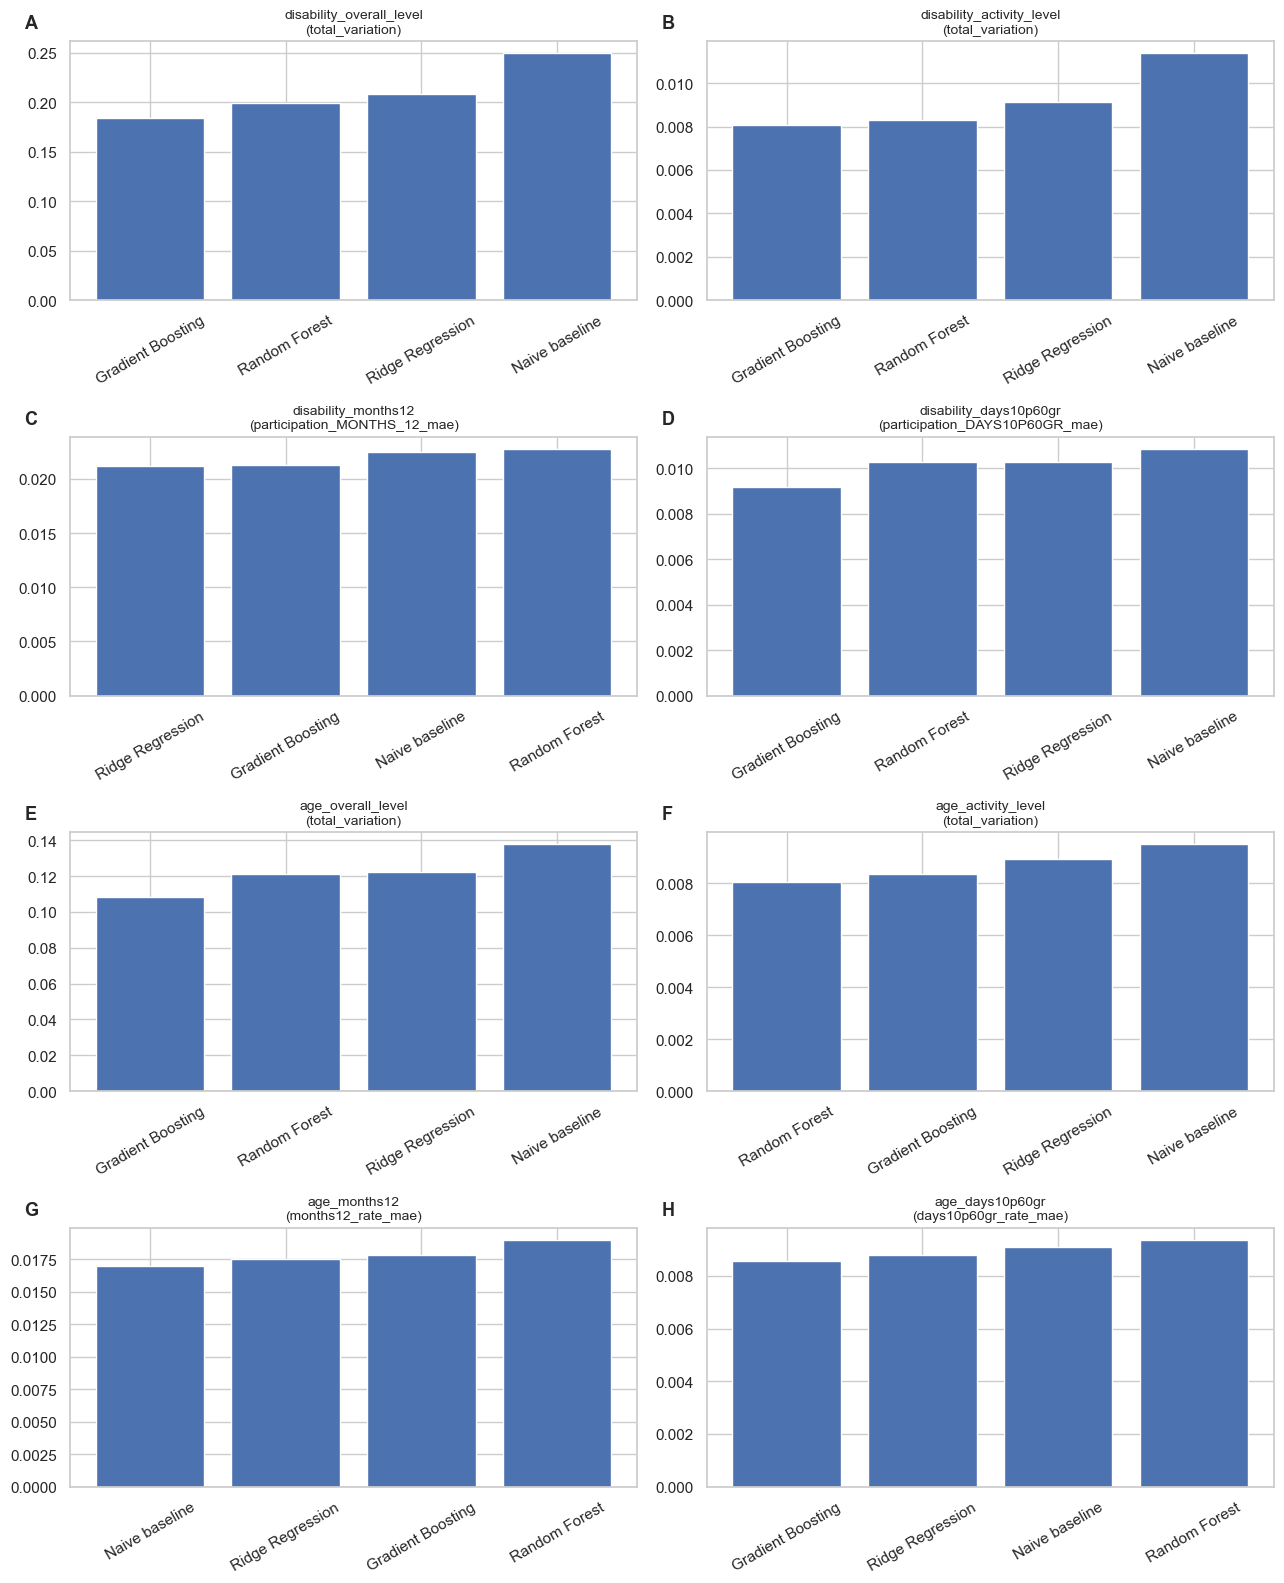

Models selected using validation results:
disability_overall_level : Gradient Boosting
disability_activity_level : Gradient Boosting
disability_months12 : Ridge Regression
disability_days10p60gr : Gradient Boosting
age_overall_level : Gradient Boosting
age_activity_level : Random Forest
age_months12 : Naive baseline
age_days10p60gr : Naive baseline


In [64]:
task_primary_metric = {
    'disability_overall_level': 'total_variation',
    'disability_activity_level': 'total_variation',
    'disability_months12': 'participation_MONTHS_12_mae',
    'disability_days10p60gr': 'participation_DAYS10P60GR_mae',
    'age_overall_level': 'total_variation',
    'age_activity_level': 'total_variation',
    'age_months12': 'months12_rate_mae',
    'age_days10p60gr': 'days10p60gr_rate_mae',
}

fig, axes = plt.subplots(4, 2, figsize=(13, 16))
for (task, metric), ax in zip(task_primary_metric.items(), axes.ravel()):
    sub = summary[summary['task'] == task].sort_values(metric)
    ax.bar(sub['model'], sub[metric], color='#4C72B0')
    ax.set_title(f'{task}\n({metric})', fontsize=10)
    ax.tick_params(axis='x', labelrotation=30)

panel_labels = list('ABCDEFGH')

for ax, label in zip(axes.ravel(), panel_labels):
    ax.text(
        -0.08, 1.05,
        label,
        transform=ax.transAxes,
        fontsize=13,
        fontweight='bold'
    )
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'figure_01_model_comparison.png', dpi=150)
plt.show()

selected_model_by_task = {}

for task, metric in task_primary_metric.items():
    task_validation = (
        validation_summary[
            validation_summary['task'] == task
        ]
        .dropna(subset=[metric])
    )

    selected_model_by_task[task] = (
        task_validation.loc[
            task_validation[metric].idxmin(),
            'model'
        ]
    )

print('Models selected using validation results:')

for task, model_name in selected_model_by_task.items():
    print(task, ':', model_name)


In [65]:
task_metric_map = {
    'age_overall_level': ('total_variation', 'TV'),
    'age_activity_level': ('total_variation', 'TV'),
    'age_months12': ('months12_rate_mae', 'MAE'),
    'age_days10p60gr': ('days10p60gr_rate_mae', 'MAE'),
    'disability_overall_level': ('total_variation', 'TV'),
    'disability_activity_level': ('total_variation', 'TV'),
    'disability_months12': ('participation_MONTHS_12_mae', 'MAE'),
    'disability_days10p60gr': ('participation_DAYS10P60GR_mae', 'MAE'),
}

compact_rows = []

for task, (metric, metric_label) in task_metric_map.items():
    selected_model = selected_model_by_task[task]

    row = summary[
        (summary['task'] == task) &
        (summary['split'] == 'test') &
        (summary['model'] == selected_model)
    ].copy()

    if row.empty:
        raise ValueError(
            f'No Year 8 test row found for {task} / {selected_model}'
        )

    if len(row) != 1:
        raise ValueError(
            f'Expected exactly one Year 8 test row for '
            f'{task} / {selected_model}, found {len(row)}'
        )

    compact_rows.append({
        'task': task,
        'selected_model': selected_model,
        'primary_metric': metric_label,
        'year8_score': row.iloc[0][metric],
    })

compact_summary = pd.DataFrame(compact_rows)

print('Year 8 performance of validation-selected models:')
display(compact_summary)

Year 8 performance of validation-selected models:


,task,selected_model,primary_metric,year8_score
0,age_overall_level,Gradient Boosting,TV,0.108290
1,age_activity_level,Random Forest,TV,0.008034
2,age_months12,Naive baseline,MAE,0.017008
3,age_days10p60gr,Naive baseline,MAE,0.009106
4,disability_overall_level,Gradient Boosting,TV,0.184113
5,disability_activity_level,Gradient Boosting,TV,0.008058
6,disability_months12,Ridge Regression,MAE,0.021213
7,disability_days10p60gr,Gradient Boosting,MAE,0.009182


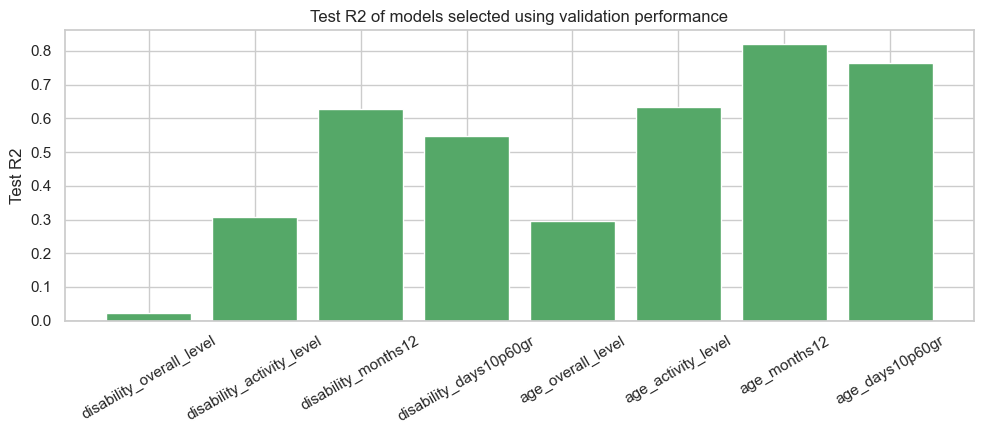

,task,selected_model,selection_metric,test_metric_value,test_r2
0,disability_overall_level,Gradient Boosting,total_variation,0.184113,0.021874
1,disability_activity_level,Gradient Boosting,total_variation,0.008058,0.307993
2,disability_months12,Ridge Regression,participation_MONTHS_12_mae,0.021213,0.626039
3,disability_days10p60gr,Gradient Boosting,participation_DAYS10P60GR_mae,0.009182,0.547536
4,age_overall_level,Gradient Boosting,total_variation,0.108290,0.296254
5,age_activity_level,Random Forest,total_variation,0.008034,0.634455
6,age_months12,Naive baseline,months12_rate_mae,0.017008,0.819348
7,age_days10p60gr,Naive baseline,days10p60gr_rate_mae,0.009106,0.764047


In [66]:
best_model_rows = []

for task, metric in task_primary_metric.items():
    selected_model = selected_model_by_task[task]

    test_row = test_summary[
        (test_summary['task'] == task)
        & (test_summary['model'] == selected_model)
    ].iloc[0]

    r2_cols = [c for c in test_row.index if c.endswith('_r2')]
    test_r2 = test_row[r2_cols].dropna().mean()

    best_model_rows.append({
        'task': task,
        'selected_model': selected_model,
        'selection_metric': metric,
        'test_metric_value': test_row[metric],
        'test_r2': test_r2,
    })

best_model_summary = pd.DataFrame(best_model_rows)

fig, ax = plt.subplots(figsize=(10, 4.5))

colors = [
    '#55A868' if value >= 0 else '#C44E52'
    for value in best_model_summary['test_r2']
]

ax.bar(
    best_model_summary['task'],
    best_model_summary['test_r2'],
    color=colors
)

ax.axhline(
    0,
    color='black',
    linewidth=0.8
)

ax.set_title(
    'Test R2 of models selected using validation performance'
)

ax.set_ylabel('Test R2')
ax.tick_params(axis='x', labelrotation=30)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / 'figure_01b_selected_model_test_r2.png',
    dpi=150
)

plt.show()

best_model_summary

## 1c. Unified model comparison table (MAE, RMSE, R2)



In [67]:
def extract_mae_rmse_r2(row):
    if pd.notna(row.get('overall_mae')):
        mae = row['overall_mae']
        rmse = row['overall_rmse']
    else:
        mae_cols = [c for c in row.index if c.endswith('_mae') and c != 'overall_mae']
        rmse_cols = [c for c in row.index if c.endswith('_rmse') and c != 'overall_rmse']
        mae = row[mae_cols].dropna().mean()
        rmse = row[rmse_cols].dropna().mean()

    r2_cols = [c for c in row.index if c.endswith('_r2')]
    r2 = row[r2_cols].dropna().mean()
    return pd.Series({'MAE': mae, 'RMSE': rmse, 'R2': r2})


comparison_table = summary[['task', 'model']].join(summary.apply(extract_mae_rmse_r2, axis=1))
comparison_table = comparison_table.sort_values(['task', 'MAE']).reset_index(drop=True)
comparison_table


,task,model,MAE,RMSE,R2
0,age_activity_level,Random Forest,0.005356,0.024105,0.634455
1,age_activity_level,Gradient Boosting,0.005562,0.024559,0.622144
2,age_activity_level,Ridge Regression,0.005958,0.026514,0.565707
3,age_activity_level,Naive baseline,0.006328,0.025180,0.555167
4,age_days10p60gr,Gradient Boosting,0.008574,0.028549,0.821145
5,age_days10p60gr,Ridge Regression,0.008792,0.029776,0.805437
6,age_days10p60gr,Naive baseline,0.009106,0.032790,0.764047
7,age_days10p60gr,Random Forest,0.009370,0.027199,0.837654
8,age_months12,Naive baseline,0.017008,0.045394,0.819348
9,age_months12,Ridge Regression,0.017509,0.044061,0.829801


### Per-metric pivot tables (task x model)


In [68]:
mae_pivot = comparison_table.pivot(index='task', columns='model', values='MAE')
rmse_pivot = comparison_table.pivot(index='task', columns='model', values='RMSE')
r2_pivot = comparison_table.pivot(index='task', columns='model', values='R2')

print('--- MAE (lower is better) ---')
print(mae_pivot.round(4))
print()
print('--- RMSE (lower is better) ---')
print(rmse_pivot.round(4))
print()
print('--- R2 (higher is better) ---')
print(r2_pivot.round(4))


--- MAE (lower is better) ---
model                      Gradient Boosting  Naive baseline  Random Forest  \
task                                                                          
age_activity_level                    0.0056          0.0063         0.0054   
age_days10p60gr                       0.0086          0.0091         0.0094   
age_months12                          0.0179          0.0170         0.0190   
age_overall_level                     0.0722          0.0918         0.0807   
disability_activity_level             0.0054          0.0076         0.0055   
disability_days10p60gr                0.0092          0.0109         0.0103   
disability_months12                   0.0212          0.0224         0.0228   
disability_overall_level              0.1227          0.1662         0.1326   

model                      Ridge Regression  
task                                         
age_activity_level                   0.0060  
age_days10p60gr                      0.00

### Best model per task, checked against more than one metric

Best-by-MAE and best-by-R2 are found independently for every task.

In [69]:
for task in comparison_table['task'].unique():
    sub = comparison_table[comparison_table['task'] == task]
    best_by_mae = sub.loc[sub['MAE'].idxmin(), 'model']
    best_by_rmse = sub.loc[sub['RMSE'].idxmin(), 'model']
    best_by_r2 = sub.loc[sub['R2'].idxmax(), 'model']

    agree = (best_by_mae == best_by_rmse == best_by_r2)
    flag = '' if agree else '  <-- metrics disagree, needs a written justification'
    print(f'{task}: best by MAE={best_by_mae}, best by RMSE={best_by_rmse}, best by R2={best_by_r2}{flag}')


age_activity_level: best by MAE=Random Forest, best by RMSE=Random Forest, best by R2=Random Forest
age_days10p60gr: best by MAE=Gradient Boosting, best by RMSE=Random Forest, best by R2=Random Forest  <-- metrics disagree, needs a written justification
age_months12: best by MAE=Naive baseline, best by RMSE=Random Forest, best by R2=Random Forest  <-- metrics disagree, needs a written justification
age_overall_level: best by MAE=Gradient Boosting, best by RMSE=Gradient Boosting, best by R2=Gradient Boosting
disability_activity_level: best by MAE=Gradient Boosting, best by RMSE=Gradient Boosting, best by R2=Gradient Boosting
disability_days10p60gr: best by MAE=Gradient Boosting, best by RMSE=Random Forest, best by R2=Random Forest  <-- metrics disagree, needs a written justification
disability_months12: best by MAE=Ridge Regression, best by RMSE=Random Forest, best by R2=Random Forest  <-- metrics disagree, needs a written justification
disability_overall_level: best by MAE=Gradient Boo

## 2. Prediction error by borough



In [70]:
def add_lag_features(frame, panel_keys, value_cols, lags=(1,),
                     rolling_window=None, covid_years=(5, 6)):
    prepared = frame.sort_values(
        panel_keys + ['year']
    ).reset_index(drop=True)

    grouped = prepared.groupby(
        panel_keys,
        sort=False
    )

    for column in value_cols:
        for lag in lags:
            prepared[f'{column}_lag{lag}'] = (
                grouped[column].shift(lag)
            )

        if rolling_window:
            prepared[f'{column}_roll{rolling_window}'] = (
                grouped[column].transform(
                    lambda s: s.shift(1).rolling(
                        rolling_window,
                        min_periods=1
                    ).mean()
                )
            )

    prepared['time_trend'] = (
        prepared['year']
        / prepared['year'].max()
    )

    prepared['is_covid_year'] = (
        prepared['year']
        .isin(covid_years)
        .astype(int)
    )

    return prepared


def alr_to_shares(values):
    values = np.clip(
        np.asarray(values, dtype=float),
        -30,
        30
    )

    exponent = np.exp(values)

    denominator = (
        1
        + exponent.sum(
            axis=1,
            keepdims=True
        )
    )

    return np.column_stack([
        exponent / denominator,
        1 / denominator
    ])


dis_level = pd.read_csv(
    DATA_DIR
    / 'RQ3_borough_disability_MEMS7GR_all_years.csv'
)

dis_level['LA_2023'] = (
    dis_level['LA_2023']
    .astype('Int64')
    .astype(str)
)

target_cols = [
    'inactive_rate',
    'fairly_active_rate',
    'active_rate'
]

panel_keys = [
    'LA_2023',
    'disability_group',
    'activity'
]

prepared = add_lag_features(
    dis_level,
    panel_keys,
    target_cols,
    lags=(1,),
    rolling_window=2
)

lag1_cols = [
    f'{column}_lag1'
    for column in target_cols
]

rolling_cols = [
    f'{column}_roll2'
    for column in target_cols
]

lag_cols = (
    lag1_cols
    + rolling_cols
)

selected_dis_level_model = (
    selected_model_by_task[
        'disability_activity_level'
    ]
)

if selected_dis_level_model == 'Ridge Regression':
    interaction_dummies = pd.get_dummies(
        prepared['disability_group'],
        prefix='disability_group_x_time'
    )

    interaction_cols = list(
        interaction_dummies.columns
    )

    prepared[interaction_cols] = (
        interaction_dummies.mul(
            prepared['time_trend'],
            axis=0
        )
    )

test = (
    prepared[
        prepared['year'] == 8
    ]
    .dropna(
        subset=target_cols + lag_cols
    )
    .copy()
)

if selected_dis_level_model == 'Naive baseline':
    predicted_shares = (
        test[lag1_cols].to_numpy()
    )

else:
    best_model = fitted_models[
        f'dis_level__{selected_dis_level_model}'
    ]

    model_features = list(
        best_model.feature_names_in_
    )

    predicted_shares = alr_to_shares(
        best_model.predict(
            test[model_features]
        )
    )

test['predicted_active_rate'] = (
    predicted_shares[:, 2]
)

test['abs_error'] = (
    test['active_rate']
    - test['predicted_active_rate']
).abs()

print(
    'Model used for subgroup error analysis:',
    selected_dis_level_model
)

Model used for subgroup error analysis: Gradient Boosting


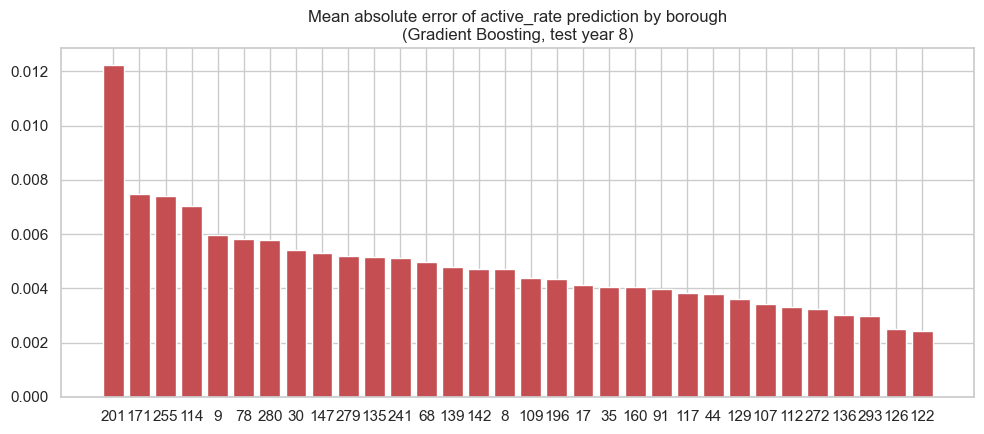

Boroughs with the largest prediction error:
LA_2023
201    0.012245
171    0.007488
255    0.007416
114    0.007031
9      0.005976
Name: abs_error, dtype: float64


In [71]:
error_by_borough = test.groupby('LA_2023')['abs_error'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(error_by_borough.index.astype(str), error_by_borough.values, color='#C44E52')
ax.set_title(
    f'Mean absolute error of active_rate prediction by borough\n'
    f'({selected_dis_level_model}, test year 8)'
)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'figure_02_error_by_borough.png', dpi=150)
plt.show()

print('Boroughs with the largest prediction error:')
print(error_by_borough.head(5))


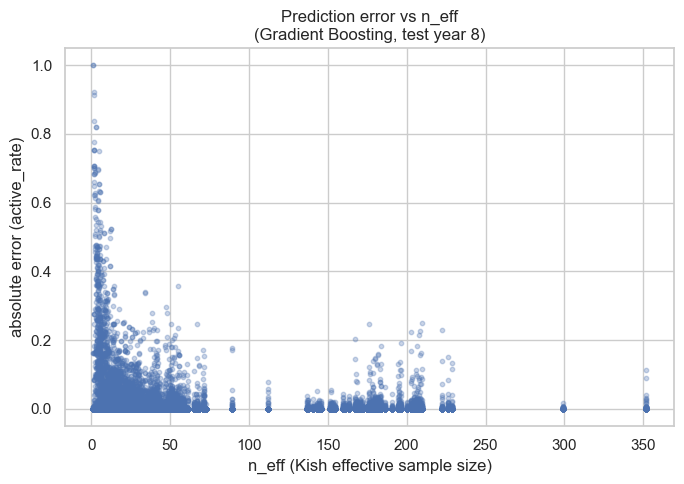

Correlation between n_eff and abs_error: 0.0028


In [72]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(test['n_eff'], test['abs_error'], alpha=0.3, s=10, color='#4C72B0')
ax.set_xlabel('n_eff (Kish effective sample size)')
ax.set_ylabel('absolute error (active_rate)')
ax.set_title(f'Prediction error vs n_eff\n({selected_dis_level_model}, test year 8)')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'figure_02b_error_vs_neff.png', dpi=150)
plt.show()

correlation = test[['n_eff', 'abs_error']].corr().iloc[0, 1]
print('Correlation between n_eff and abs_error:', round(correlation, 4))

In [73]:
test["sample_size_group"] = np.where(test["n"] < 30, "n < 30", "n >= 30")

small_sample_error = test.groupby("sample_size_group").agg(
    cells=("abs_error", "size"),
    mean_mae=("abs_error", "mean"),
    median_mae=("abs_error", "median"),
    rmse=("abs_error", lambda x: np.sqrt(np.mean(x ** 2))),
    mean_observed_rate=("active_rate", "mean"),
    zero_rate=("active_rate", lambda x: (x == 0).mean())
).reset_index()

positive_sample_error = test[test["active_rate"] > 0].groupby("sample_size_group").agg(
    positive_cells=("abs_error", "size"),
    positive_cell_mae=("abs_error", "mean")
).reset_index()

small_sample_error = small_sample_error.merge(positive_sample_error, on="sample_size_group", how="left")

print("Overall Year 8 active-rate MAE:", round(test["abs_error"].mean(), 4))
print("Positive-cell Year 8 active-rate MAE:", round(test.loc[test["active_rate"] > 0, "abs_error"].mean(), 4))
print(small_sample_error.round(4).to_string(index=False))

small_sample_error.to_csv(OUTPUT_DIR / "year8_activity_level_error_by_raw_sample_size.csv", index=False)

Overall Year 8 active-rate MAE: 0.0048
Positive-cell Year 8 active-rate MAE: 0.0693
sample_size_group  cells  mean_mae  median_mae   rmse  mean_observed_rate  zero_rate  positive_cells  positive_cell_mae
           n < 30  42560    0.0049         0.0 0.0385              0.0056     0.9699            1282             0.1539
          n >= 30  19832    0.0046         0.0 0.0203              0.0082     0.8550            2875             0.0316


## 3. Prediction error by disability group


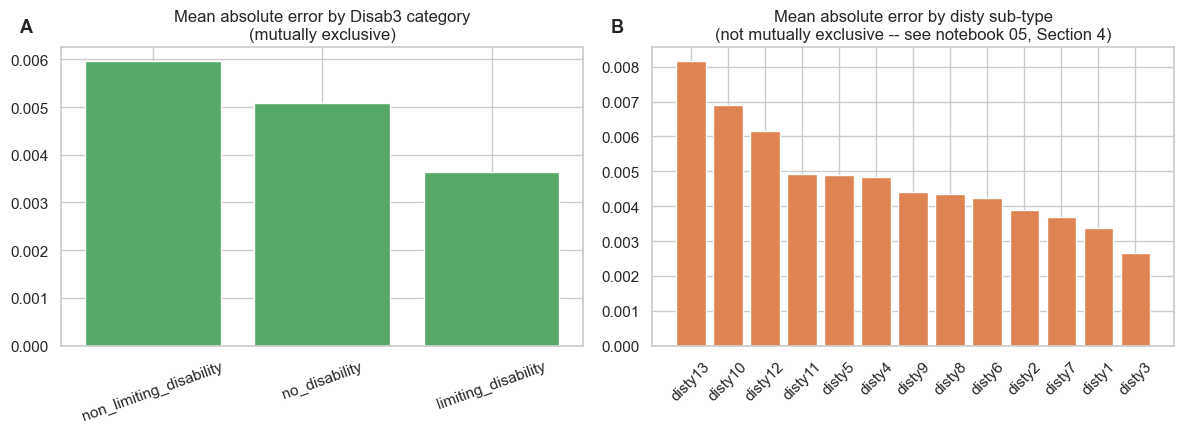

In [74]:
disab3_labels = {'limiting_disability', 'non_limiting_disability', 'no_disability'}
disty_labels = {f'disty{i}' for i in range(1, 14)}

error_by_group = test.groupby('disability_group')['abs_error'].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

disab3_error = error_by_group[error_by_group.index.isin(disab3_labels)].sort_values(ascending=False)
axes[0].bar(disab3_error.index, disab3_error.values, color='#55A868')
axes[0].text(-0.08, 1.05, 'A', transform=axes[0].transAxes, fontsize=13, fontweight='bold')
axes[0].set_title('Mean absolute error by Disab3 category\n(mutually exclusive)')
axes[0].tick_params(axis='x', labelrotation=20)

disty_error = error_by_group[error_by_group.index.isin(disty_labels)].sort_values(ascending=False)
axes[1].bar(disty_error.index, disty_error.values, color='#DD8452')
axes[1].text(-0.08, 1.05, 'B', transform=axes[1].transAxes, fontsize=13, fontweight='bold')
axes[1].set_title('Mean absolute error by disty sub-type\n(not mutually exclusive -- see notebook 05, Section 4)')
axes[1].tick_params(axis='x', labelrotation=45)

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'figure_03_error_by_disability_group.png', dpi=150)
plt.show()


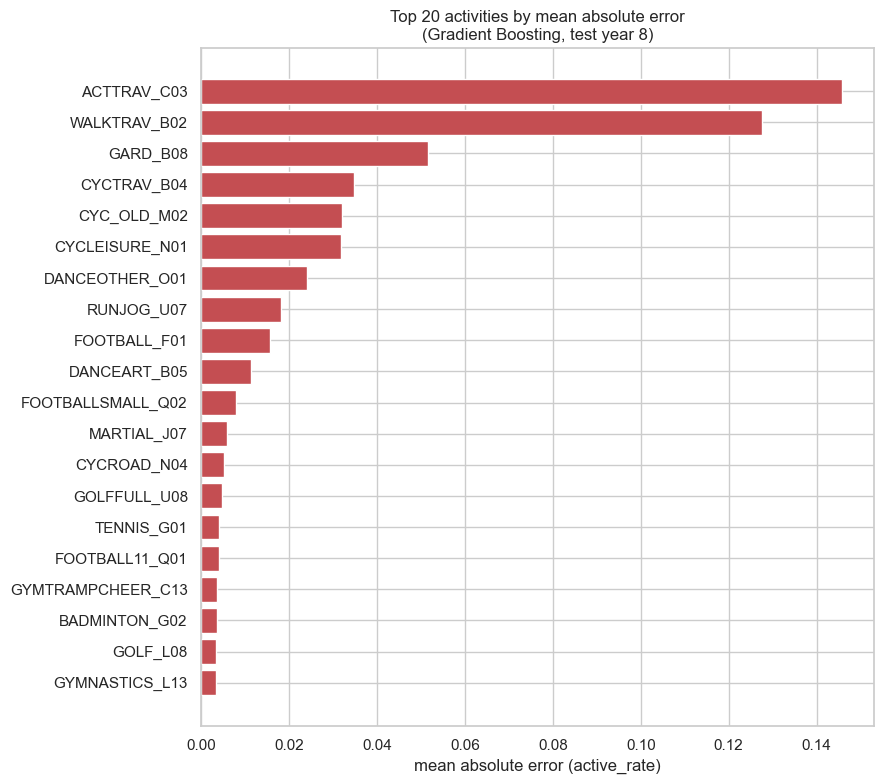

Activities with the largest prediction error:
activity
ACTTRAV_C03       0.145753
WALKTRAV_B02      0.127519
GARD_B08          0.051720
CYCTRAV_B04       0.034685
CYC_OLD_M02       0.032150
CYCLEISURE_N01    0.031839
DANCEOTHER_O01    0.024021
RUNJOG_U07        0.018264
FOOTBALL_F01      0.015598
DANCEART_B05      0.011376
Name: abs_error, dtype: float64


In [75]:
error_by_activity = test.groupby('activity')['abs_error'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(error_by_activity.head(20).index[::-1], error_by_activity.head(20).values[::-1], color='#C44E52')
ax.set_title(f'Top 20 activities by mean absolute error\n({selected_dis_level_model}, test year 8)')
ax.set_xlabel('mean absolute error (active_rate)')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'figure_03b_error_by_activity.png', dpi=150)
plt.show()

print('Activities with the largest prediction error:')
print(error_by_activity.head(10))

## 4. Overall-level table vs activity-specific table


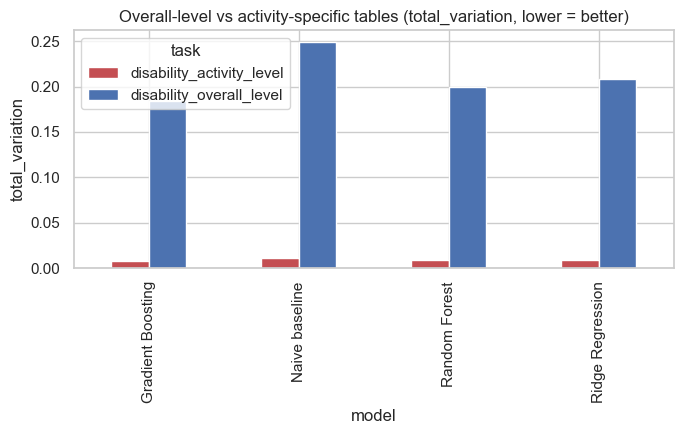

task               disability_activity_level  disability_overall_level
model                                                                 
Gradient Boosting                   0.008058                  0.184113
Naive baseline                      0.011372                  0.249353
Random Forest                       0.008300                  0.198923
Ridge Regression                    0.009148                  0.207858


In [76]:
compare_tasks = summary[summary['task'].isin(['disability_overall_level', 'disability_activity_level'])]
pivot = compare_tasks.pivot(index='model', columns='task', values='total_variation')

fig, ax = plt.subplots(figsize=(7, 4.5))
pivot.plot(kind='bar', ax=ax, color=['#C44E52', '#4C72B0'])
ax.set_title('Overall-level vs activity-specific tables (total_variation, lower = better)')
ax.set_ylabel('total_variation')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'figure_04_overall_vs_activity_level.png', dpi=150)
plt.show()

print(pivot)


## 5. Highest predicted participation activity across boroughs and groups

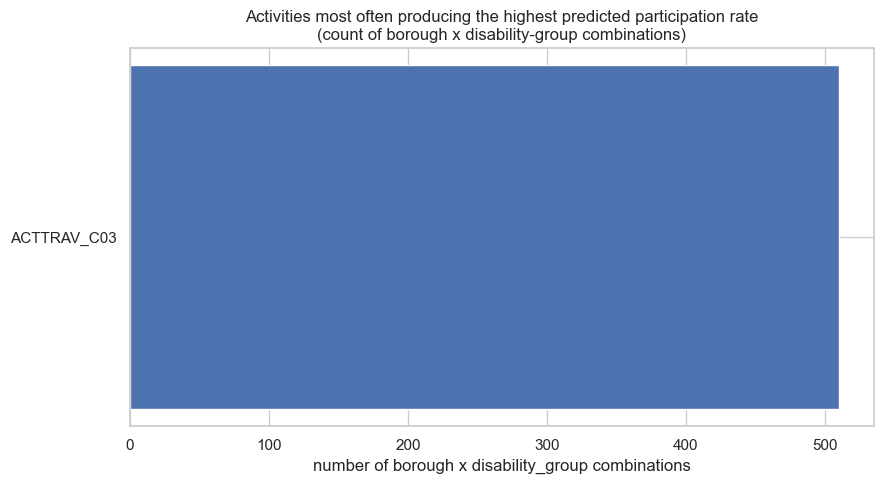

activity
ACTTRAV_C03    510
Name: count, dtype: int64


In [77]:
activity_win_counts = top_activity['activity'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(activity_win_counts.index[::-1], activity_win_counts.values[::-1], color='#4C72B0')
ax.set_title(
    'Activities most often producing the highest predicted participation rate\n'
    '(count of borough x disability-group combinations)'
)
ax.set_xlabel('number of borough x disability_group combinations')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'figure_05_top_activity_distribution.png', dpi=150)
plt.show()

print(activity_win_counts)


## 6. Subgroup error diagnostics

In [78]:
borough_error_summary = (
    test.assign(
        squared_error=(
            test['active_rate']
            - test['predicted_active_rate']
        ) ** 2,
        observed_zero=(
            test['active_rate'] == 0
        ).astype(int)
    )
    .groupby('LA_2023')
    .agg(
        mean_absolute_error=('abs_error', 'mean'),
        median_absolute_error=('abs_error', 'median'),
        rmse=('squared_error', lambda x: np.sqrt(x.mean())),
        observed_zero_share=('observed_zero', 'mean'),
        number_of_cells=('abs_error', 'size')
    )
    .sort_values('mean_absolute_error', ascending=False)
)

print('Borough-level error summary:')
print(borough_error_summary.round(6))

print()
print('Five boroughs with the highest mean absolute error:')
print(borough_error_summary.head(5).round(6))

borough_mae_range = (
    borough_error_summary['mean_absolute_error'].max()
    - borough_error_summary['mean_absolute_error'].min()
)

print()
print('Range of borough-level mean absolute error:', round(borough_mae_range, 6))

Borough-level error summary:
         mean_absolute_error  median_absolute_error      rmse  \
LA_2023                                                         
201                 0.012245               0.000001  0.071565   
171                 0.007488               0.000001  0.044784   
255                 0.007416               0.000001  0.049302   
114                 0.007031               0.000001  0.039850   
9                   0.005976               0.000001  0.033850   
78                  0.005819               0.000001  0.035956   
280                 0.005791               0.000001  0.036253   
30                  0.005405               0.000001  0.046964   
147                 0.005289               0.000001  0.029263   
279                 0.005190               0.000001  0.036945   
135                 0.005173               0.000001  0.036602   
241                 0.005107               0.000001  0.032915   
68                  0.004982               0.000001  0.031827

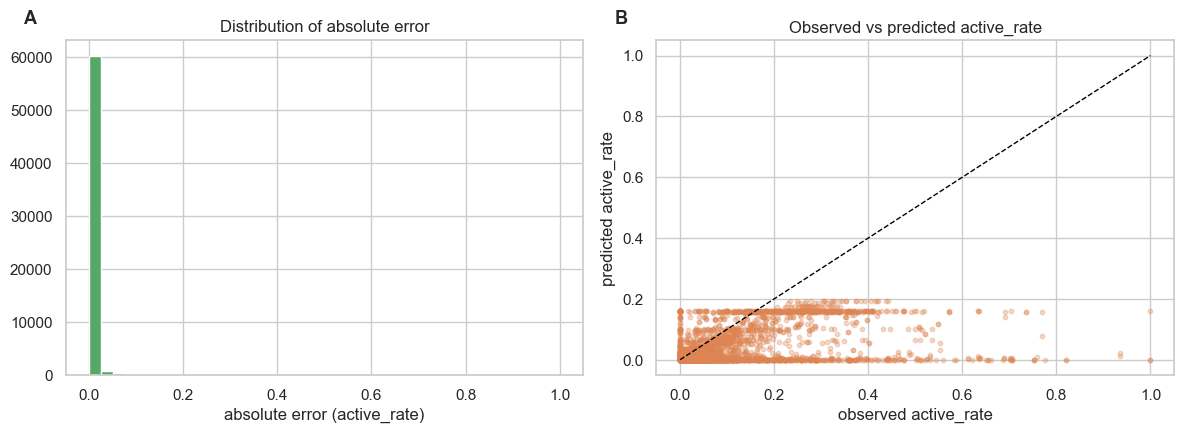

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(test['abs_error'], bins=40, color='#55A868')
axes[0].text(-0.08, 1.05, 'A', transform=axes[0].transAxes, fontsize=13, fontweight='bold')
axes[0].set_title('Distribution of absolute error')
axes[0].set_xlabel('absolute error (active_rate)')

axes[1].scatter(test['active_rate'], test['predicted_active_rate'], alpha=0.3, s=10, color='#DD8452')
axes[1].plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=1)
axes[1].text(-0.08, 1.05, 'B', transform=axes[1].transAxes, fontsize=13, fontweight='bold')
axes[1].set_title('Observed vs predicted active_rate')
axes[1].set_xlabel('observed active_rate')
axes[1].set_ylabel('predicted active_rate')

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'figure_06b_residual_distribution.png', dpi=150)
plt.show()

In [80]:
from scipy import stats

paired_group_error = (
    test[
        test['disability_group'].isin([
            'limiting_disability',
            'non_limiting_disability'
        ])
    ]
    .groupby(['LA_2023', 'disability_group'])['abs_error']
    .mean()
    .unstack('disability_group')
    .dropna()
)

paired_group_error['paired_difference'] = (
    paired_group_error['non_limiting_disability']
    - paired_group_error['limiting_disability']
)

wilcoxon_result = stats.wilcoxon(
    paired_group_error['non_limiting_disability'],
    paired_group_error['limiting_disability'],
    alternative='two-sided'
)

print('Number of paired boroughs:', len(paired_group_error))
print(
    'Median borough-level MAE, non-limiting disability:',
    paired_group_error['non_limiting_disability'].median()
)
print(
    'Median borough-level MAE, limiting disability:',
    paired_group_error['limiting_disability'].median()
)
print(
    'Median paired difference:',
    paired_group_error['paired_difference'].median()
)
print(
    'Wilcoxon signed-rank p-value:',
    wilcoxon_result.pvalue
)

paired_group_error.head()

Number of paired boroughs: 32
Median borough-level MAE, non-limiting disability: 0.006079260776519255
Median borough-level MAE, limiting disability: 0.0035251354126127595
Median paired difference: 0.002353734681086595
Wilcoxon signed-rank p-value: 4.397472366690636e-05


disability_group,limiting_disability,non_limiting_disability,paired_difference
LA_2023,,,
107,0.002680,0.005239,0.002559
109,0.002461,0.008085,0.005624
112,0.002975,0.004432,0.001457
114,0.008262,0.006552,-0.001709
117,0.001449,0.002448,0.000999


In [81]:
positive_rate_test = test[
    test['active_rate'] > 0
].copy()

positive_cell_error = (
    positive_rate_test
    .groupby('disability_group')['abs_error']
    .agg(
        mean_absolute_error='mean',
        median_absolute_error='median',
        number_of_cells='size'
    )
    .sort_values('mean_absolute_error', ascending=False)
)

zero_cell_share = 1 - (
    len(positive_rate_test) / len(test)
)

print('Share of test cells with observed active_rate = 0:', round(zero_cell_share, 4))
print()
print('Error among cells with observed active_rate > 0:')
print(positive_cell_error.round(6))

Share of test cells with observed active_rate = 0: 0.9334

Error among cells with observed active_rate > 0:
                         mean_absolute_error  median_absolute_error  \
disability_group                                                      
disty11                             0.309130               0.262288   
disty13                             0.306010               0.264862   
disty10                             0.281685               0.245040   
disty6                              0.228402               0.178361   
disty9                              0.186953               0.162473   
disty12                             0.152272               0.117942   
disty4                              0.135637               0.110797   
disty8                              0.132989               0.093172   
disty7                              0.089858               0.061308   
disty5                              0.068889               0.049133   
disty2                              0.06

## 6b. Age-group held-out error and n_eff diagnostics"

In [82]:
def build_task_predictions(
    frame, panel_keys, target_cols, weight_col,
    task_name, model_prefix, selected_model_by_task, fitted_models_dict,
    is_composition, extra_lag=None, rolling_window=2,
):
    prepared = add_lag_features(
        frame, panel_keys, target_cols,
        lags=(1,) if extra_lag is None else (1, 2),
        rolling_window=rolling_window if extra_lag == 'roll2' else None,
    )
    lag1_cols = [f'{c}_lag1' for c in target_cols]
    if extra_lag == 'lag2':
        extra_cols = [f'{c}_lag2' for c in target_cols]
    elif extra_lag == 'roll2':
        extra_cols = [f'{c}_roll2' for c in target_cols]
    else:
        extra_cols = []
    lag_cols = lag1_cols + extra_cols

    model_name = selected_model_by_task[task_name]

    if model_name == 'Ridge Regression':
        dummies = pd.get_dummies(prepared[panel_keys[1]], prefix=f'{panel_keys[1]}_x_time')
        prepared[list(dummies.columns)] = dummies.mul(prepared['time_trend'], axis=0)

    test_rows = prepared[prepared['year'] == 8].dropna(subset=target_cols + lag_cols).copy()

    if model_name == 'Naive baseline':
        predicted = test_rows[lag1_cols].to_numpy(dtype=float)
    else:
        model = fitted_models_dict[f'{model_prefix}__{model_name}']
        feature_cols = list(model.feature_names_in_)
        raw_pred = model.predict(test_rows[feature_cols])
        predicted = alr_to_shares(raw_pred) if is_composition else np.clip(raw_pred, 0, 1).reshape(-1, 1)

    for i, col in enumerate(target_cols):
        test_rows[f'predicted_{col}'] = predicted[:, i]
        test_rows[f'abs_error_{col}'] = (test_rows[col] - test_rows[f'predicted_{col}']).abs()

    if is_composition:
        test_rows['abs_error'] = test_rows[[f'abs_error_{c}' for c in target_cols]].sum(axis=1) * 0.5
    else:
        test_rows['abs_error'] = test_rows[f'abs_error_{target_cols[0]}']

    return test_rows, model_name

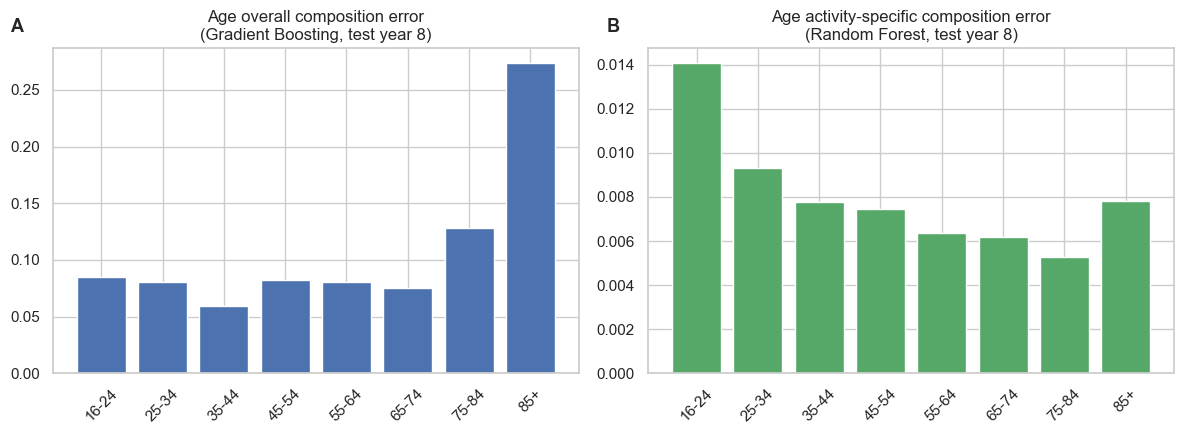

               mean    median  count
age_group                           
16-24      0.085143  0.077167     32
25-34      0.080754  0.072521     32
35-44      0.059746  0.051247     32
45-54      0.082678  0.068813     32
55-64      0.080862  0.061070     32
65-74      0.075243  0.067938     32
75-84      0.128492  0.112575     32
85+        0.273405  0.248757     32
               mean    median  count
age_group                           
16-24      0.014059  0.000003   3968
25-34      0.009333  0.000003   3968
35-44      0.007749  0.000003   3968
45-54      0.007457  0.000003   3968
55-64      0.006380  0.000003   3968
65-74      0.006201  0.000003   3968
75-84      0.005291  0.000003   3968
85+        0.007794  0.000003   3809


In [83]:
age_overall_df = pd.read_csv(AGE_DATA_DIR / 'q3_age_overall_activity_level_panel.csv')
age_activity_df = pd.read_csv(AGE_DATA_DIR / 'q3_age_activity_participation_level_panel_complete.csv')
for df in [age_overall_df, age_activity_df]:
    df['LA_2023'] = (
        df['LA_2023']
        .astype('Int64')
        .astype(str)
    )
age_overall_test, age_overall_model = build_task_predictions(
    age_overall_df, ['LA_2023', 'age_group'],
    ['overall_inactive_rate', 'overall_fairly_active_rate', 'overall_active_rate'],
    'weighted_n_overall_activity_level',
    task_name='age_overall_level', model_prefix='age_overall',
    selected_model_by_task=selected_model_by_task, fitted_models_dict=fitted_models,
    is_composition=True, extra_lag='lag2',
)

age_activity_test, age_activity_model = build_task_predictions(
    age_activity_df, ['LA_2023', 'age_group', 'activity_suffix'],
    ['activity_inactive_rate', 'activity_fairly_active_rate', 'activity_active_rate'],
    'weighted_n_activity_level',
    task_name='age_activity_level', model_prefix='age_level',
    selected_model_by_task=selected_model_by_task, fitted_models_dict=fitted_models,
    is_composition=True, extra_lag='roll2',
)

age_group_error_overall = age_overall_test.groupby('age_group')['abs_error'].agg(['mean', 'median', 'count'])
age_group_error_activity = age_activity_test.groupby('age_group')['abs_error'].agg(['mean', 'median', 'count'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(age_group_error_overall.index, age_group_error_overall['mean'], color='#4C72B0')
axes[0].text(-0.08, 1.05, 'A', transform=axes[0].transAxes, fontsize=13, fontweight='bold')
axes[0].set_title(f'Age overall composition error\n({age_overall_model}, test year 8)')
axes[0].tick_params(axis='x', labelrotation=45)

axes[1].bar(age_group_error_activity.index, age_group_error_activity['mean'], color='#55A868')
axes[1].text(-0.08, 1.05, 'B', transform=axes[1].transAxes, fontsize=13, fontweight='bold')
axes[1].set_title(f'Age activity-specific composition error\n({age_activity_model}, test year 8)')
axes[1].tick_params(axis='x', labelrotation=45)

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'figure_07_age_group_error.png', dpi=150)
plt.show()

print(age_group_error_overall)
print(age_group_error_activity)

     subset  mean_abs_error    n
0       all        0.108290  256
1  n_eff<20        0.239762   46
2  n_eff<30        0.187376   74
3  n_eff<50        0.136277  150
     subset  mean_abs_error      n
0       all        0.008034  31585
1  n_eff<20        0.007116   7029
2  n_eff<30        0.007573  11084
3  n_eff<50        0.007798  21462


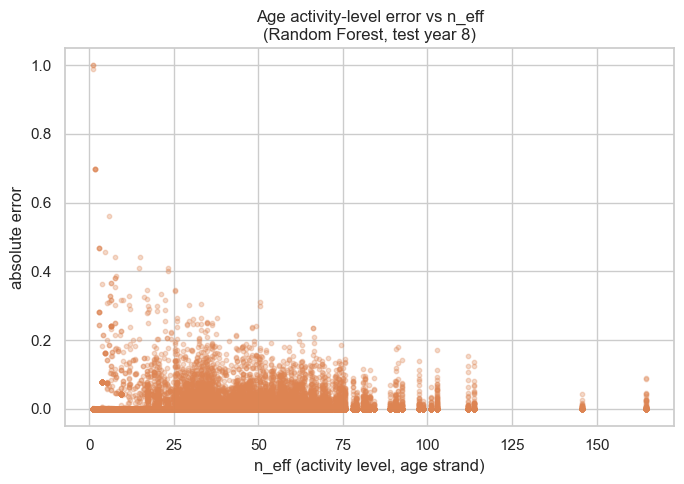

In [84]:
neff_thresholds = [20, 30, 50]

def neff_error_table(test_df, neff_col):
    rows = []
    rows.append({'subset': 'all', 'mean_abs_error': test_df['abs_error'].mean(), 'n': len(test_df)})
    for t in neff_thresholds:
        sub = test_df[test_df[neff_col] < t]
        rows.append({'subset': f'n_eff<{t}', 'mean_abs_error': sub['abs_error'].mean(), 'n': len(sub)})
    return pd.DataFrame(rows)

age_overall_neff_table = neff_error_table(age_overall_test, 'n_eff_overall_activity_level')
age_activity_neff_table = neff_error_table(age_activity_test, 'n_eff_activity_level')

print(age_overall_neff_table)
print(age_activity_neff_table)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(age_activity_test['n_eff_activity_level'], age_activity_test['abs_error'], alpha=0.3, s=10, color='#DD8452')
ax.set_xlabel('n_eff (activity level, age strand)')
ax.set_ylabel('absolute error')
ax.set_title(f'Age activity-level error vs n_eff\n({age_activity_model}, test year 8)')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'figure_08_age_error_vs_neff.png', dpi=150)
plt.show()

In [85]:
age_months12_df = pd.read_csv(AGE_DATA_DIR / 'q3_age_activity_participation_level_panel_complete.csv')

age_months12_test, age_months12_model = build_task_predictions(
    age_months12_df, ['LA_2023', 'age_group', 'activity_suffix'],
    ['months12_rate'], 'weighted_n_months12',
    task_name='age_months12', model_prefix='age_months12',
    selected_model_by_task=selected_model_by_task, fitted_models_dict=fitted_models,
    is_composition=False, extra_lag='roll2',
)

age_days_test, age_days_model = build_task_predictions(
    age_months12_df, ['LA_2023', 'age_group', 'activity_suffix'],
    ['days10p60gr_rate'], 'weighted_n_days10p60gr',
    task_name='age_days10p60gr', model_prefix='age_days',
    selected_model_by_task=selected_model_by_task, fitted_models_dict=fitted_models,
    is_composition=False, extra_lag='roll2',
)

rate_neff_table = pd.concat([
    neff_error_table(age_months12_test, 'n_eff_months12').assign(task='age_months12'),
    neff_error_table(age_days_test, 'n_eff_days10p60gr').assign(task='age_days10p60gr'),
], ignore_index=True)

rate_neff_table

,subset,mean_abs_error,n,task
0,all,0.017008,31585,age_months12
1,n_eff<20,0.017398,7029,age_months12
2,n_eff<30,0.017932,11084,age_months12
3,n_eff<50,0.017261,21462,age_months12
4,all,0.009106,31585,age_days10p60gr
5,n_eff<20,0.010257,7029,age_days10p60gr
6,n_eff<30,0.010032,11084,age_days10p60gr
7,n_eff<50,0.009384,21462,age_days10p60gr


## 7. Exploratory feature importance for tree-based models

In [86]:
from sklearn.multioutput import MultiOutputRegressor


def get_feature_importance(fitted_model, top_n=15):
    preprocess = fitted_model.named_steps['preprocess']
    model = fitted_model.named_steps['model']
    feature_names = preprocess.get_feature_names_out()

    if isinstance(model, MultiOutputRegressor):
        per_target = np.array([est.feature_importances_ for est in model.estimators_])
        importances = per_target.mean(axis=0)
    else:
        importances = model.feature_importances_

    series = pd.Series(importances, index=feature_names)
    return series.sort_values(ascending=False).head(top_n)


def plot_feature_importance(ax, fitted_model, title):
    top = get_feature_importance(fitted_model)
    ax.barh(top.index[::-1], top.values[::-1], color='#4C72B0')
    ax.set_title(title, fontsize=9)
    ax.tick_params(axis='y', labelsize=7)


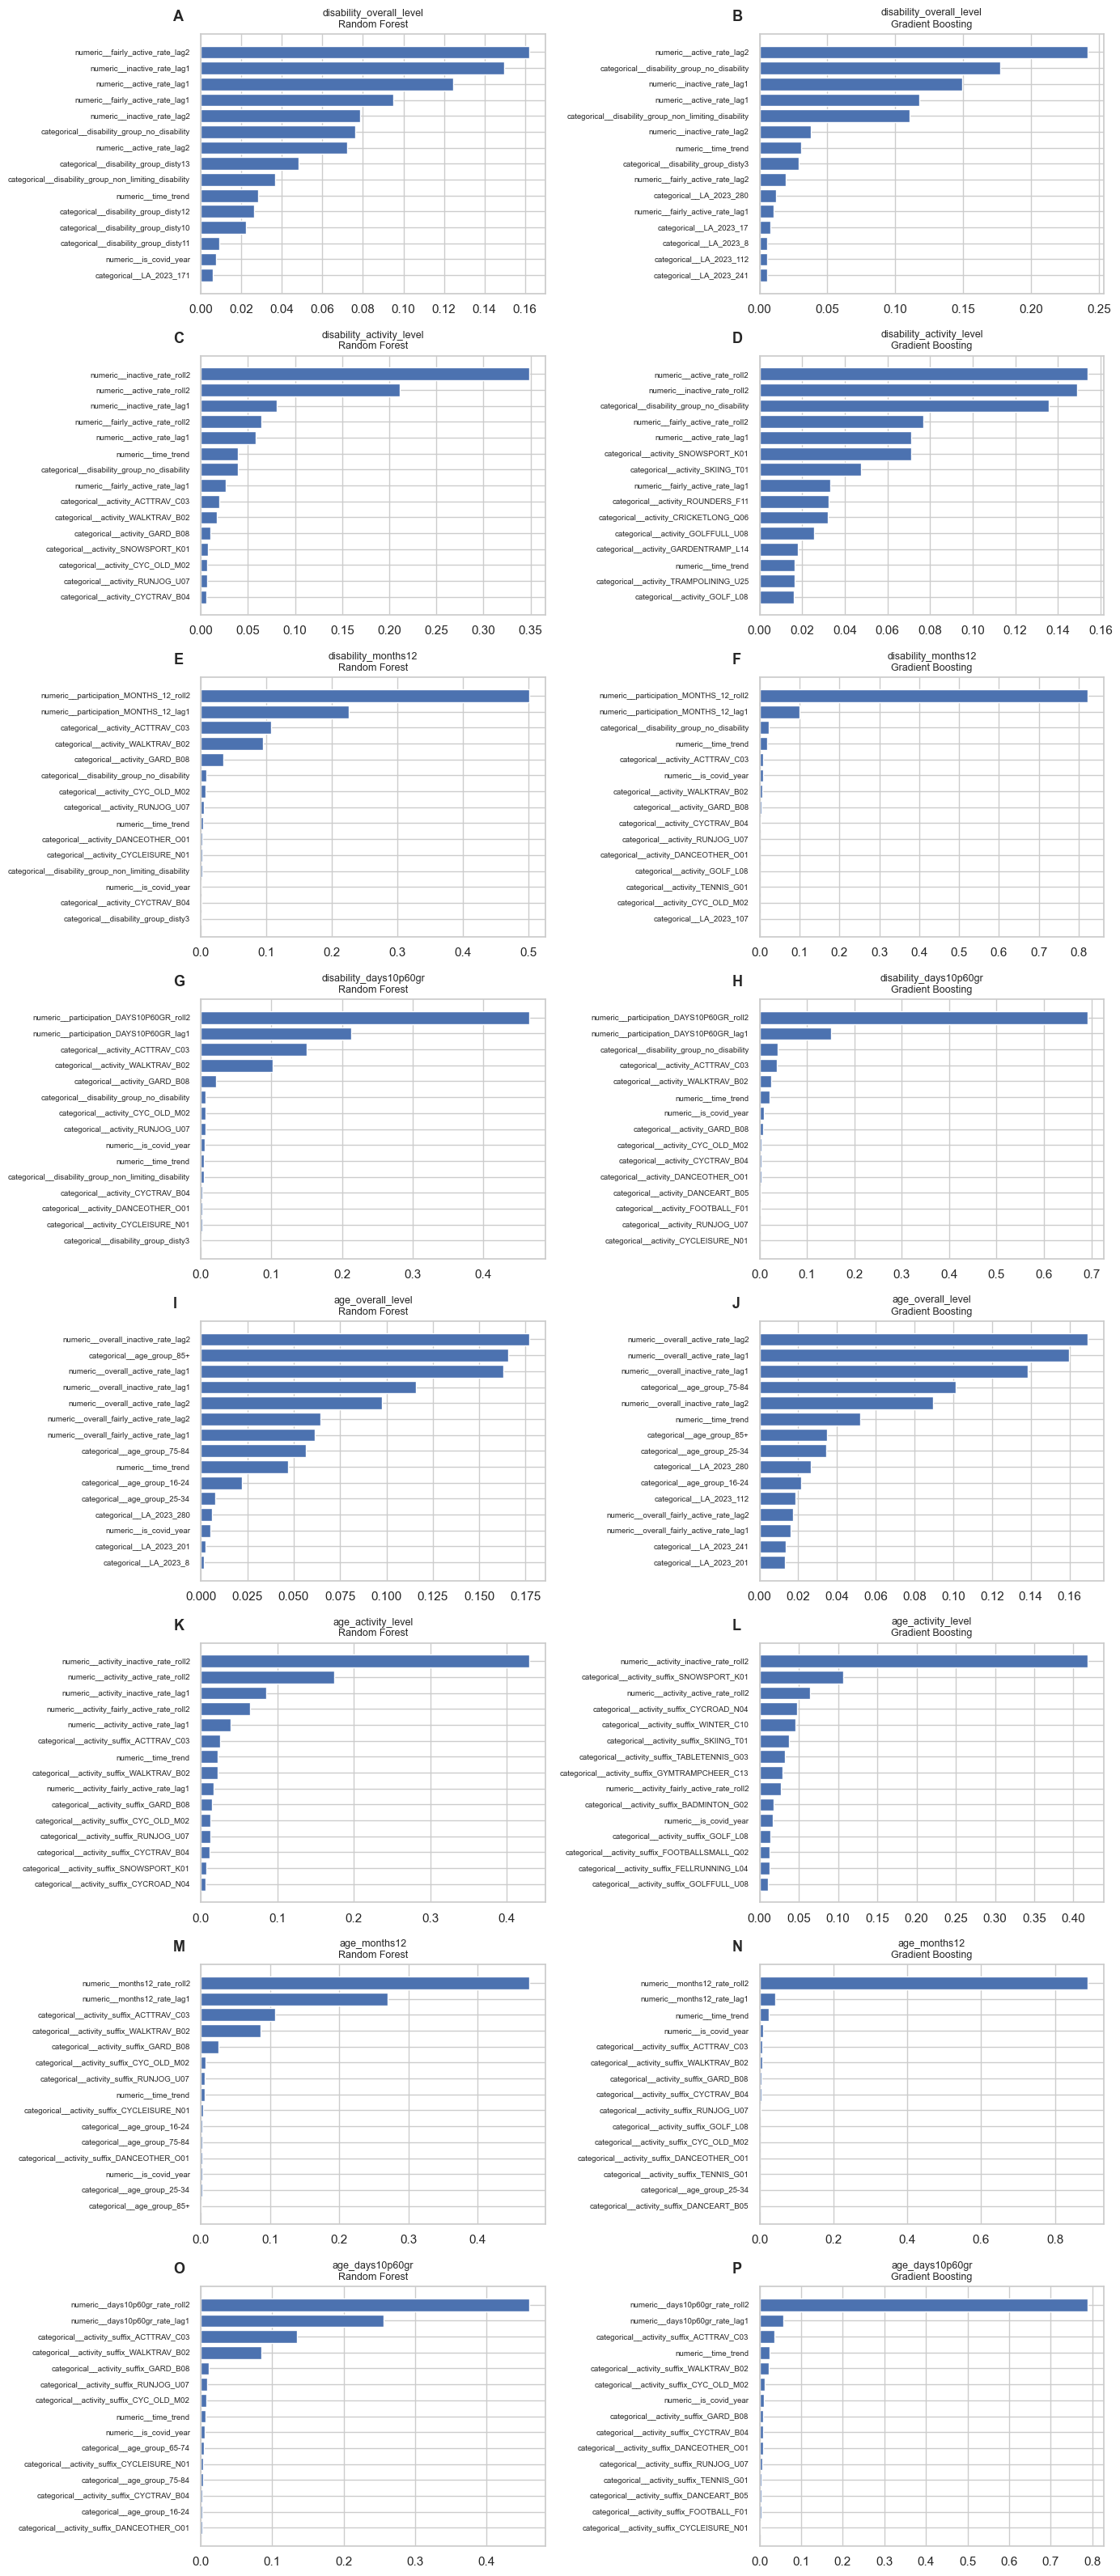

In [87]:
task_model_prefix = {
    'disability_overall_level': 'dis_overall',
    'disability_activity_level': 'dis_level',
    'disability_months12': 'months12',
    'disability_days10p60gr': 'days',
    'age_overall_level': 'age_overall',
    'age_activity_level': 'age_level',
    'age_months12': 'age_months12',
    'age_days10p60gr': 'age_days',
}

tree_model_names = [
    'Random Forest',
    'Gradient Boosting'
]

n_tasks = len(task_model_prefix)

fig, axes = plt.subplots(
    n_tasks,
    2,
    figsize=(14, 4 * n_tasks)
)

for row, (task_name, key_prefix) in enumerate(
    task_model_prefix.items()
):
    for col, model_name in enumerate(
        tree_model_names
    ):
        ax = axes[row, col]

        fitted_model = fitted_models[
            f'{key_prefix}__{model_name}'
        ]

        plot_feature_importance(
            ax,
            fitted_model,
            title=f'{task_name}\n{model_name}'
        )

panel_labels = list('ABCDEFGHIJKLMNOP')

for ax, label in zip(axes.ravel(), panel_labels):
    ax.text(
        -0.08, 1.05,
        label,
        transform=ax.transAxes,
        fontsize=13,
        fontweight='bold'
    )
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / 'figure_06_tree_model_feature_importance.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()